# Car Price Prediction - Multiple Regression Models

# 1. Loading and Preprocessing

In [2]:
# Import The Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [3]:
# Load the Dataset
df = pd.read_csv("CarPrice_Assignment.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

Dataset loaded successfully!
Shape: 205 rows × 26 columns



In [4]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [6]:
# Summary Statistics
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [7]:
# Check missing values
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

* No missing values was found therefore no imputation was required

In [8]:
# Check Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


* No duplicate record were identified, indicating that the dataset was already clean and consistent.

In [9]:
# Drop car_ID
df.drop(columns = ["car_ID"], inplace=True)

* The car_ID column was removed as it is a unique identifier and does not contribute to predicting car prices.

In [10]:
print(df["CarName"].head())

print(df['CarName'].nunique())

0          alfa-romero giulia
1         alfa-romero stelvio
2    alfa-romero Quadrifoglio
3                 audi 100 ls
4                  audi 100ls
Name: CarName, dtype: object
147


In [11]:
# Extract Car Brand fron CarName
df["CarBrand"] = df["CarName"].apply(lambda x: x.split()[0].lower())

print(df['CarBrand'].nunique())

27


* The manufacturer name was extracted from CarName to retain meaningful brand information while reducing feature complexity

In [12]:
# Check Brand Names
print(df['CarBrand'].value_counts())

CarBrand
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
dodge           9
volkswagen      9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
jaguar          3
chevrolet       3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
mercury         1
porcshce        1
Name: count, dtype: int64


In [13]:
# Correct Inconsistencies
df["CarBrand"] = df['CarBrand'].replace({
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota'
})

* Inconsistent brand spellings were standardized to ensure accurate gouping and analysis of manufacturers

In [14]:
print(df['CarBrand'].unique())

['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']


In [15]:
# Drop the row CarName
df.drop(columns=['CarName'], inplace=True)

* The original CarName column was removed as it contianed many unique model names and could introduce unnecessary dimensionality

In [16]:

print(df.dtypes)

symboling             int64
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
CarBrand             object
dtype: object


In [17]:
# Check Categorical Variables
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    
    print(df[col].nunique())
    
    print(df[col].unique())


fueltype
2
['gas' 'diesel']

aspiration
2
['std' 'turbo']

doornumber
2
['two' 'four']

carbody
5
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

drivewheel
3
['rwd' 'fwd' '4wd']

enginelocation
2
['front' 'rear']

enginetype
7
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']

cylindernumber
7
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

fuelsystem
8
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']

CarBrand
22
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']


In [19]:
# Convert Text-Based Numeric Columns
df['doornumber'] = df['doornumber'].map({'two': 2, 'four': 4})

df['cylindernumber'] = df['cylindernumber'].map({
    'two'   : 2,
    'three' : 3,
    'four'  : 4,
    'five'  : 5,
    'six'   : 6,
    'eight' : 8,
    'twelve': 12
})

# Verify the Nulss Introduced by Mapping
print(df[['doornumber', 'cylindernumber']].isnull().sum())

doornumber        0
cylindernumber    0
dtype: int64


* The doornumber variable was converted from text labels to numeric values to preserve its quantitative meaning as a count feature.
* The cylindernumber variable was transformed into numerical form so that the models could utilize the actual engine cylinder count.

In [20]:
# Encode Remaining Categorical Variable
# --- Binary Categorical Columns---

df['fueltype'] = df['fueltype'].map({'gas': 0, 'diesel': 1})
df['aspiration'] = df['aspiration'].map({'std': 0,'turbo': 1})
df['enginelocation'] = df['enginelocation'].map({'front': 0, 'rear':1})

* Binary columns (fueltype, aspiration, enginelocation) were mapped to 0/1 explicitly for transparency.

In [21]:
# --- Multi-Categorical nominal columns ---
# One-Hot Encoding via get_dummies

multi_cols = [
    'carbody',
    'drivewheel',
    'enginetype',
    'fuelsystem',
    'CarBrand'
]

df = pd.get_dummies(df, columns= multi_cols, drop_first=True, dtype=int)

print("Shape after encoding:", df.shape)

print(df.head())

Shape after encoding: (205, 60)
   symboling  fueltype  aspiration  doornumber  enginelocation  wheelbase  \
0          3         0           0           2               0       88.6   
1          3         0           0           2               0       88.6   
2          1         0           0           2               0       94.5   
3          2         0           0           4               0       99.8   
4          2         0           0           4               0       99.4   

   carlength  carwidth  carheight  curbweight  ...  CarBrand_nissan  \
0      168.8      64.1       48.8        2548  ...                0   
1      168.8      64.1       48.8        2548  ...                0   
2      171.2      65.5       52.4        2823  ...                0   
3      176.6      66.2       54.3        2337  ...                0   
4      176.6      66.4       54.3        2824  ...                0   

   CarBrand_peugeot  CarBrand_plymouth  CarBrand_porsche  CarBrand_renault  \


* Multi-category nominal variables were transformed using One-Hot Encoding to represent categories numerically

# 2. Train-Test Split and Feature Scaling

In [22]:
# Import Libraries 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features
X = df.drop(columns=['price'])
y = df['price']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (205, 59)
y shape: (205,)


In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test= train_test_split( X,y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (164, 59)
Test set size: (41, 59)


In [24]:
# Feature Scaling
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling complete
X_train_scaled shape: (164, 59)
X_test_scaled shape: (41, 59)


# 3. Model Implementation

In [25]:
# Import libraries
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Define models
models = {
    "Linear Regression"        : (LinearRegression(), X_train_scaled, X_test_scaled),
    "Decision Tree"            : (DecisionTreeRegressor(random_state= 42), X_train, X_test),
    "Random Forest"            : (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    "Gradient Boosting"        : (GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test),
    "Support Vector Regressor" : (SVR(kernel='rbf'), X_train_scaled, X_test_scaled)
}

# Train All Models 
trained_models ={}

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)

    trained_models[name] = (model, X_te)
    print(f"{name} - trained successfully")
    

Linear Regression - trained successfully
Decision Tree - trained successfully
Random Forest - trained successfully
Gradient Boosting - trained successfully
Support Vector Regressor - trained successfully


# 4. Model Evaluation

In [26]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = []
for name, (model, X_te) in trained_models.items():
    y_pred = model.predict(X_te)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R²"   : round(r2, 4),
        "MSE"  : round(mse, 2),
        "MAE"  : round(mae, 2)   
    })
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

                   Model      R²         MSE     MAE
           Random Forest  0.9577  3343086.97 1285.09
       Gradient Boosting  0.9281  5678838.06 1681.26
           Decision Tree  0.9022  7722717.65 1935.27
       Linear Regression  0.8951  8283565.72 1942.07
Support Vector Regressor -0.1008 86898072.68 5701.89


* Random Forest achieved the highest R² score (0.9577) and the lowest MSE and MAE values, indicating the best predictive performance among all models. Gradient Boosting also performed well, while Decision Tree and Linear Regression showed moderate performance. Support Vector Regressor performed poorly with a negative R² score, suggesting that it was unable to model the relationship between the features and car price effectively.


# 5. Feature Importance Analysis

             Feature  Importance
0         enginesize    0.546512
1         curbweight    0.298487
2         highwaympg    0.045817
3         horsepower    0.031925
4           carwidth    0.013119
5       CarBrand_bmw    0.007655
6          carlength    0.007368
7          wheelbase    0.007204
8            citympg    0.006278
9            peakrpm    0.004923
10         boreratio    0.004874
11            stroke    0.004042
12  compressionratio    0.003520
13         carheight    0.003076
14    cylindernumber    0.001944


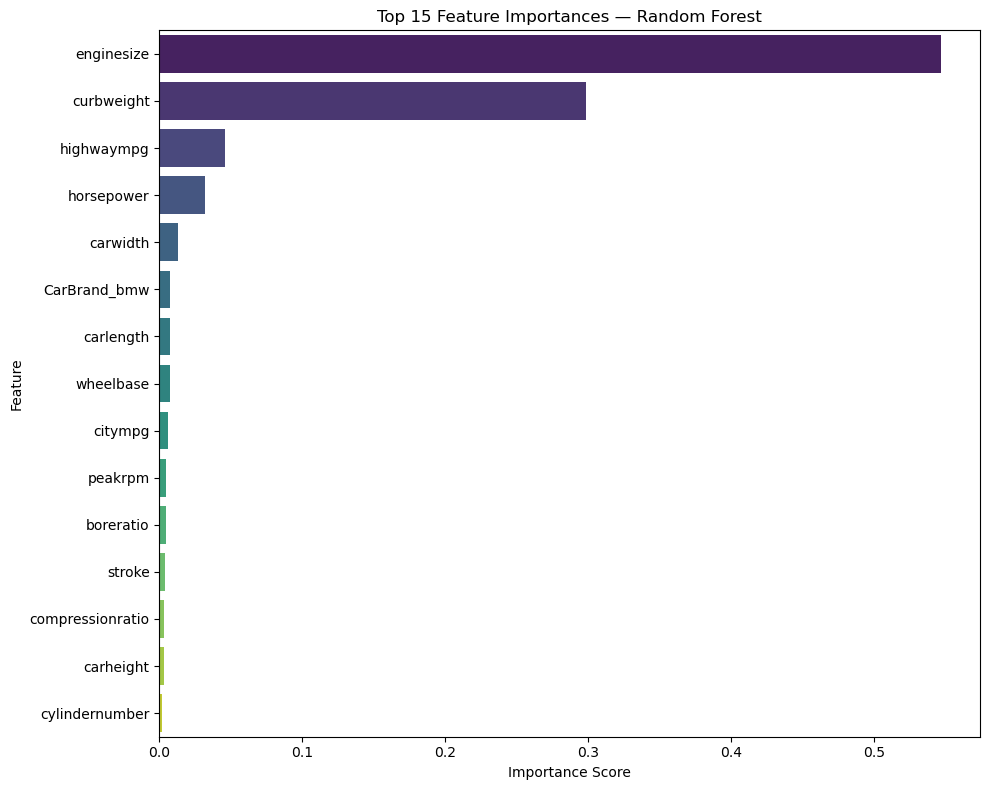

In [27]:
# Extract Feature Importances

rf_model = trained_models["Random Forest"][0]
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_ 

# Create a DataFrame and sorting of important feature

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)
print(feat_imp_df.head(15))

# Visualize
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp_df.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

* The feature importance analysis revealed that engine size was the most influential factor affecting car prices, followed by curb weight. Variables such as highway mpg, horsepower, and car width also contributed to price prediction, but with considerably lower importance.
* The results indicate that vehicle performance and physical dimensions play a major role in determining car prices in the American market.
* Additionally, certain brand-related features, such as BMW, showed a modest but measurable influence on pricing, reflecting the impact of brand value on vehicle cost.

# 6. Hyperparameter Tuning

In [28]:
from sklearn.model_selection import GridSearchCV


In [29]:
# Define Parameter Grid

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#  Run GridSearchCV 

rf_tuned = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1)

rf_tuned.fit(X_train, y_train)

print("Best Parameters:", rf_tuned.best_params_)

print("Best CV R²     :", round(rf_tuned.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²     : 0.8899


In [30]:
# Evaluate tuned model on test set 
y_pred_tuned = rf_tuned.best_estimator_.predict(X_test)

r2_tuned  = r2_score(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

# Compare baseline vs tuned
comparison_df = pd.DataFrame([
    {'Model': 'Random Forest (Baseline)', 'R²': 0.9577, 'MSE': 3343086.97, 'MAE': 1285.09},
    {'Model': 'Random Forest (Tuned)',    'R²': round(r2_tuned, 4),
                                          'MSE': round(mse_tuned, 2),
                                          'MAE': round(mae_tuned, 2)}
])

print(comparison_df.to_string(index=False))

                   Model     R²        MSE     MAE
Random Forest (Baseline) 0.9577 3343086.97 1285.09
   Random Forest (Tuned) 0.9585 3275883.07 1222.09


* Hyperparameter tuning using GridSearchCV resulted in a slight improvement in model performance. The tuned model achieved a slight improvement over the baseline model, with the R² score increasing from 0.9577 to 0.9585 and the MAE decreasing from 1285.09 to 1222.00.
* However, the improvement was modest, suggesting that the baseline model was already well-suited to the dataset.

# Conclusion :

Among the five regression models evaluated, Random Forest Regressor was identified as the best performing model with an R² of 0.9577, explaining approximately 96% of variance in car prices. Engine size and curb weight emerged as the most significant pricing factors, confirming that vehicle performance and physical dimensions are the primary drivers of car prices in the American market. These insights can guide the management in making informed decisions on vehicle design and pricing strategy.